# VoxCeleb2 AAC Duration Analysis

This notebook scans the VoxCeleb2 AAC tree, measures the duration of every `.m4a` sample, and summarizes length distributions.

Expected layout:

```text
/home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac/
  id00012/
    21Uxsk56VDQ/
      00001.m4a
      00002.m4a
      ...
```

Outputs include:
- total file count and speaker count
- per-file durations
- duration buckets (grouped lengths)
- histogram / boxplot views
- per-speaker duration summary
- optional CSV exports


In [14]:
import io
import json
import struct
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')


In [15]:
# ===== Config =====
DATA_ROOT = Path('/home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac')
AUDIO_SUFFIXES = {'.m4a'}

# Duration bins in seconds.
DURATION_BINS = [0, 1, 2, 3, 4, 5, 7.5, 10, 15, 20, 30, np.inf]
DURATION_LABELS = [
    '0-1s', '1-2s', '2-3s', '3-4s', '4-5s',
    '5-7.5s', '7.5-10s', '10-15s', '15-20s', '20-30s', '30s+'
]

OUTPUT_DIR = Path('./voxceleb2_duration_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_ROOT =', DATA_ROOT)
print('Exists    =', DATA_ROOT.exists())
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())


DATA_ROOT = /home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac
Exists    = True
OUTPUT_DIR = /home/SpeakerRec/BioVoice/vox2_explained/voxceleb2_duration_outputs


In [16]:
# ===== Duration reader =====
# Pure-Python MP4/M4A metadata parser. No extra pip installs required.
CONTAINER_ATOMS = {'moov', 'trak', 'mdia', 'minf', 'stbl', 'edts', 'udta', 'meta'}

def _read_atom_header(fh: io.BufferedReader):
    header = fh.read(8)
    if len(header) < 8:
        return None, None, None

    size, atom_type = struct.unpack('>I4s', header)
    atom_type = atom_type.decode('ascii', errors='replace')
    header_size = 8

    if size == 1:
        extended = fh.read(8)
        if len(extended) < 8:
            return None, None, None
        size = struct.unpack('>Q', extended)[0]
        header_size = 16
    elif size == 0:
        current = fh.tell()
        fh.seek(0, 2)
        end = fh.tell()
        fh.seek(current)
        size = end - (current - 8)

    return size, atom_type, header_size

def _parse_mvhd_duration(fh: io.BufferedReader, payload_size: int) -> float:
    payload = fh.read(payload_size)
    if len(payload) < 20:
        raise ValueError('mvhd payload too short')

    version = payload[0]
    if version == 0:
        if len(payload) < 20:
            raise ValueError('mvhd v0 payload too short')
        timescale = struct.unpack('>I', payload[12:16])[0]
        duration = struct.unpack('>I', payload[16:20])[0]
    elif version == 1:
        if len(payload) < 32:
            raise ValueError('mvhd v1 payload too short')
        timescale = struct.unpack('>I', payload[20:24])[0]
        duration = struct.unpack('>Q', payload[24:32])[0]
    else:
        raise ValueError(f'unsupported mvhd version: {version}')

    if timescale <= 0:
        raise ValueError(f'invalid timescale: {timescale}')
    return float(duration) / float(timescale)

def _find_duration_in_atoms(fh: io.BufferedReader, end_offset: int) -> Optional[float]:
    while fh.tell() < end_offset:
        atom_start = fh.tell()
        atom_size, atom_type, header_size = _read_atom_header(fh)
        if atom_size is None or atom_size < header_size:
            break

        atom_end = atom_start + atom_size
        payload_size = atom_size - header_size

        if atom_type == 'mvhd':
            return _parse_mvhd_duration(fh, payload_size)

        if atom_type in CONTAINER_ATOMS:
            child_start = fh.tell()
            if atom_type == 'meta':
                fh.seek(4, 1)
                child_start += 4
            duration = _find_duration_in_atoms(fh, atom_end)
            if duration is not None:
                return duration
            fh.seek(atom_end)
        else:
            fh.seek(atom_end)

    return None

def get_audio_duration_seconds(path: Path) -> float:
    with path.open('rb') as fh:
        fh.seek(0, 2)
        file_size = fh.tell()
        fh.seek(0)
        duration = _find_duration_in_atoms(fh, file_size)

    if duration is None:
        raise RuntimeError(f'Could not parse MP4/M4A duration from metadata: {path}')
    return duration


def safe_rel_parts(path: Path, root: Path) -> tuple[Optional[str], Optional[str], str]:
    rel = path.relative_to(root)
    parts = rel.parts
    speaker_id = parts[0] if len(parts) >= 1 else None
    video_id = parts[1] if len(parts) >= 2 else None
    return speaker_id, video_id, str(rel)


In [17]:
# ===== Discover files =====
audio_files = []
if DATA_ROOT.exists():
    audio_files = sorted(
        p for p in DATA_ROOT.rglob('*')
        if p.is_file() and p.suffix.lower() in AUDIO_SUFFIXES
    )

print(f'Found {len(audio_files):,} audio files')
if audio_files:
    print('Example:', audio_files[0])
else:
    print('No matching audio files were found. Check DATA_ROOT and AUDIO_SUFFIXES.')

speaker_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()]) if DATA_ROOT.exists() else []
print(f'Found {len(speaker_dirs):,} speaker directories')


Found 16,301 audio files
Example: /home/SpeakerRec/BioVoice/data/datasets/voxceleb2/voxceleb2_hf/extracted_aac/aac/id00012/21Uxsk56VDQ/00001.m4a
Found 100 speaker directories


In [18]:
# ===== Scan durations =====
RECORD_COLUMNS = ['speaker_id', 'video_id', 'file_name', 'relative_path', 'duration_sec', 'duration_ms']
records = []
errors = []

for audio_path in tqdm(audio_files, desc='Reading durations'):
    try:
        duration_sec = get_audio_duration_seconds(audio_path)
        speaker_id, video_id, relative_path = safe_rel_parts(audio_path, DATA_ROOT)
        records.append({
            'speaker_id': speaker_id,
            'video_id': video_id,
            'file_name': audio_path.name,
            'relative_path': relative_path,
            'duration_sec': duration_sec,
            'duration_ms': duration_sec * 1000.0,
        })
    except Exception as exc:
        errors.append({'path': str(audio_path), 'error': repr(exc)})

durations_df = pd.DataFrame(records, columns=RECORD_COLUMNS)
errors_df = pd.DataFrame(errors)

print('Scanned rows :', len(durations_df))
print('Errors       :', len(errors_df))
if len(audio_files) == 0:
    print('Scan result: no files discovered under DATA_ROOT.')
elif len(durations_df) == 0:
    print('Scan result: files were discovered, but duration extraction failed for all of them.')
if len(errors_df) > 0:
    display(errors_df.head(10))


Reading durations: 100%|██████████| 16301/16301 [00:03<00:00, 4702.50it/s]

Scanned rows : 16301
Errors       : 0


In [19]:
# ===== Add grouped duration buckets =====
if durations_df.empty:
    print('durations_df is empty. Fix the scan step above before continuing.')
else:
    durations_df['duration_bucket'] = pd.cut(
        durations_df['duration_sec'],
        bins=DURATION_BINS,
        labels=DURATION_LABELS,
        include_lowest=True,
        right=False,
    )

    durations_df['duration_rounded_sec'] = durations_df['duration_sec'].round(2)
    durations_df = durations_df.sort_values(['speaker_id', 'video_id', 'file_name']).reset_index(drop=True)

durations_df.head()


,speaker_id,video_id,file_name,relative_path,duration_sec,duration_ms,duration_bucket,duration_rounded_sec
0,id00012,21Uxsk56VDQ,00001.m4a,id00012/21Uxsk56VDQ/00001.m4a,9.465,9465.0,7.5-10s,9.46
1,id00012,21Uxsk56VDQ,00002.m4a,id00012/21Uxsk56VDQ/00002.m4a,15.345,15345.0,15-20s,15.34
2,id00012,21Uxsk56VDQ,00003.m4a,id00012/21Uxsk56VDQ/00003.m4a,9.985,9985.0,7.5-10s,9.98
3,id00012,21Uxsk56VDQ,00004.m4a,id00012/21Uxsk56VDQ/00004.m4a,5.105,5105.0,5-7.5s,5.11
4,id00012,21Uxsk56VDQ,00005.m4a,id00012/21Uxsk56VDQ/00005.m4a,4.305,4305.0,4-5s,4.30


In [20]:
# ===== High-level summary =====
if durations_df.empty:
    summary = pd.Series({
        'num_speakers': 0,
        'num_videos': 0,
        'num_files': 0,
        'min_sec': np.nan,
        'max_sec': np.nan,
        'mean_sec': np.nan,
        'median_sec': np.nan,
        'std_sec': np.nan,
        'total_hours': 0.0,
    })
else:
    summary = pd.Series({
        'num_speakers': durations_df['speaker_id'].nunique(),
        'num_videos': durations_df['video_id'].nunique(),
        'num_files': len(durations_df),
        'min_sec': durations_df['duration_sec'].min(),
        'max_sec': durations_df['duration_sec'].max(),
        'mean_sec': durations_df['duration_sec'].mean(),
        'median_sec': durations_df['duration_sec'].median(),
        'std_sec': durations_df['duration_sec'].std(),
        'total_hours': durations_df['duration_sec'].sum() / 3600.0,
    })

summary.round(3).to_frame('value')


,value
num_speakers,100.000
num_videos,2258.000
num_files,16301.000
min_sec,3.985
max_sec,81.025
mean_sec,7.363
median_sec,5.905
std_sec,4.519
total_hours,33.342


In [21]:
# ===== Group by duration bucket =====
if durations_df.empty:
    bucket_summary = pd.DataFrame(columns=['duration_bucket', 'num_samples', 'pct_samples', 'avg_sec', 'min_sec', 'max_sec'])
else:
    bucket_summary = (
        durations_df
        .groupby('duration_bucket', dropna=False)
        .agg(
            num_samples=('relative_path', 'count'),
            avg_sec=('duration_sec', 'mean'),
            min_sec=('duration_sec', 'min'),
            max_sec=('duration_sec', 'max'),
        )
        .reset_index()
    )
    bucket_summary['pct_samples'] = 100.0 * bucket_summary['num_samples'] / max(len(durations_df), 1)
    bucket_summary = bucket_summary[['duration_bucket', 'num_samples', 'pct_samples', 'avg_sec', 'min_sec', 'max_sec']]

bucket_summary.round(3)


,duration_bucket,num_samples,pct_samples,avg_sec,min_sec,max_sec
0,0-1s,0,0.000,NaN,NaN,NaN
1,1-2s,0,0.000,NaN,NaN,NaN
2,2-3s,0,0.000,NaN,NaN,NaN
3,3-4s,254,1.558,3.985,3.985,3.985
4,4-5s,5005,30.704,4.462,4.025,4.985
5,5-7.5s,6030,36.992,6.054,5.025,7.465
6,7.5-10s,2394,14.686,8.583,7.505,9.985
7,10-15s,1757,10.778,11.973,10.025,14.985
8,15-20s,511,3.135,17.076,15.025,19.985
9,20-30s,255,1.564,23.917,20.025,29.985


In [22]:
# ===== Speaker-level summary =====
if durations_df.empty:
    speaker_summary = pd.DataFrame(columns=['speaker_id', 'num_samples', 'num_videos', 'min_sec', 'mean_sec', 'median_sec', 'max_sec', 'total_minutes'])
else:
    speaker_summary = (
        durations_df
        .groupby('speaker_id')
        .agg(
            num_samples=('relative_path', 'count'),
            num_videos=('video_id', 'nunique'),
            min_sec=('duration_sec', 'min'),
            mean_sec=('duration_sec', 'mean'),
            median_sec=('duration_sec', 'median'),
            max_sec=('duration_sec', 'max'),
            total_minutes=('duration_sec', lambda x: x.sum() / 60.0),
        )
        .sort_values(['num_samples', 'total_minutes'], ascending=[False, False])
        .reset_index()
    )

speaker_summary.head(20).round(3)


,speaker_id,num_samples,num_videos,min_sec,mean_sec,median_sec,max_sec,total_minutes
0,id00176,489,41,3.985,6.868,5.865,30.505,55.978
1,id00078,462,41,3.985,8.208,6.345,45.705,63.198
2,id00064,452,32,3.985,12.017,8.785,57.305,90.525
3,id00084,434,30,3.985,6.765,5.585,27.585,48.931
4,id00022,431,39,3.985,8.453,6.745,36.825,60.724
5,id00159,427,29,3.985,6.717,5.705,20.465,47.806
6,id00020,422,51,3.985,6.755,5.905,18.465,47.509
7,id00086,393,41,3.985,6.423,5.505,19.785,42.073
8,id00076,385,47,3.985,8.767,6.945,35.985,56.257
9,id00033,381,25,3.985,7.207,6.025,33.305,45.763


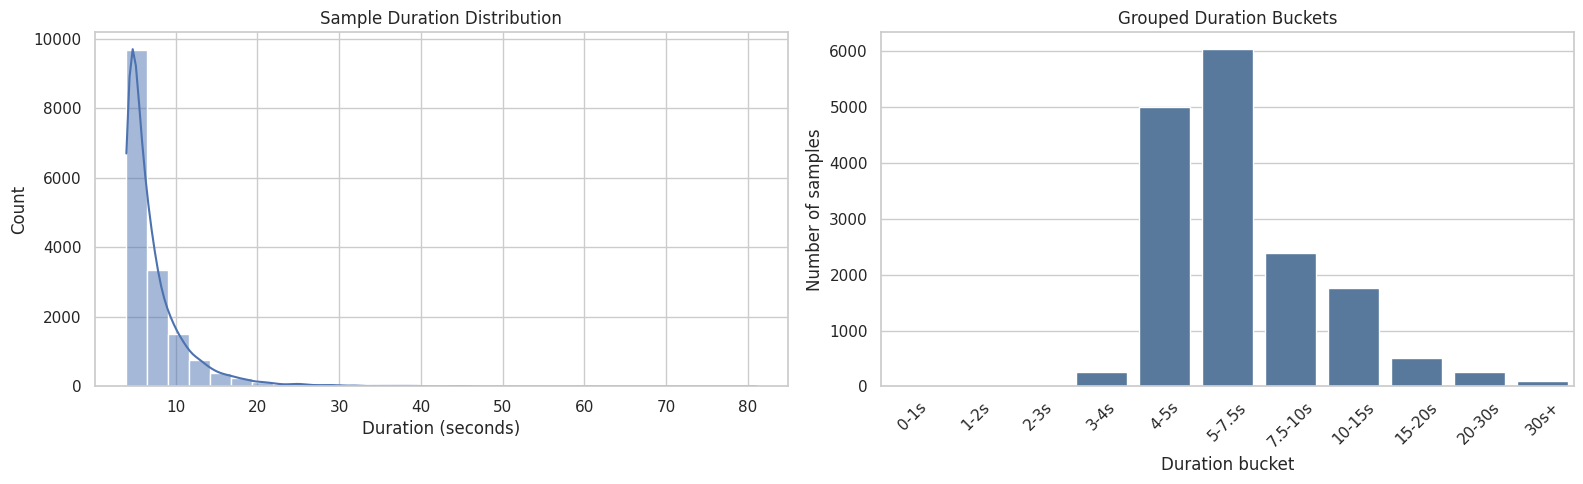

In [ ]:
# ===== Distribution plots =====
if durations_df.empty:
    print('No plots to show because durations_df is empty.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(durations_df['duration_sec'], bins=50, kde=True, ax=axes[0])
    axes[0].set_title('Sample Duration Distribution')
    axes[0].set_xlabel('Duration (seconds)')

    sns.barplot(data=bucket_summary, x='duration_bucket', y='num_samples', ax=axes[1], color='#4C78A8')
    axes[1].set_title('Grouped Duration Buckets')
    axes[1].set_xlabel('Duration bucket')
    axes[1].set_ylabel('Number of samples')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


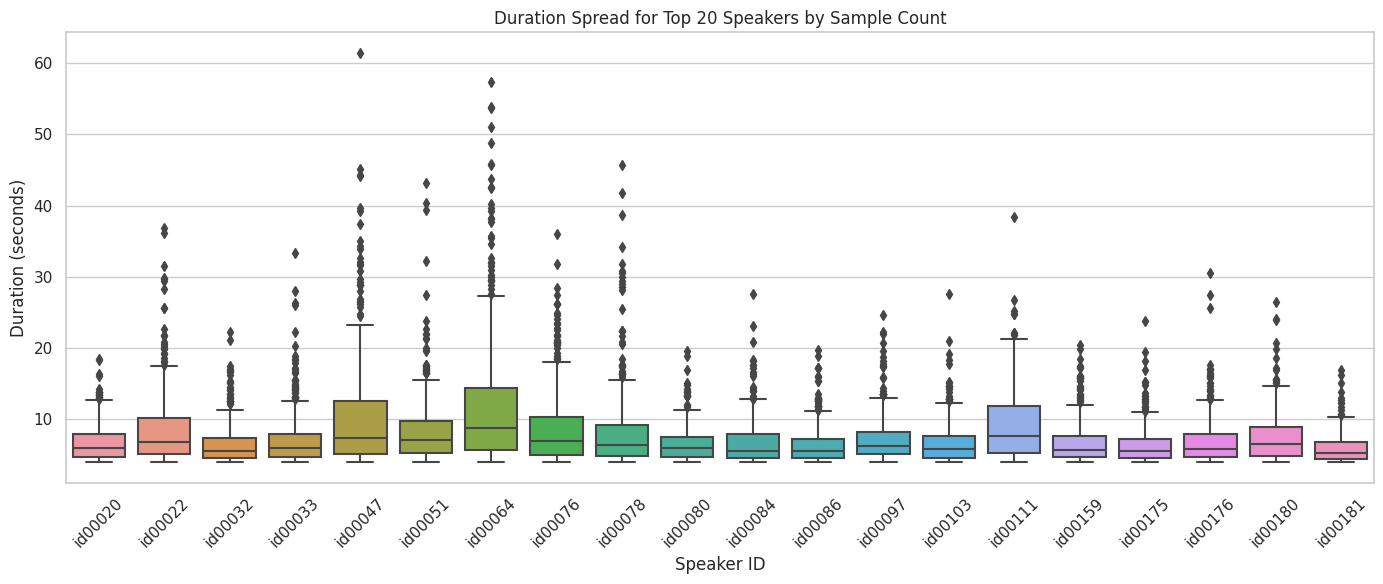

In [24]:
# ===== Speaker spread plot =====
if durations_df.empty:
    print('No speaker spread plot because durations_df is empty.')
else:
    top_n = 20
    top_speakers = speaker_summary.head(top_n)['speaker_id']
    plot_df = durations_df[durations_df['speaker_id'].isin(top_speakers)].copy()

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=plot_df, x='speaker_id', y='duration_sec')
    plt.title(f'Duration Spread for Top {top_n} Speakers by Sample Count')
    plt.xlabel('Speaker ID')
    plt.ylabel('Duration (seconds)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [25]:
# ===== Longest / shortest samples =====
if durations_df.empty:
    print('No samples to display because durations_df is empty.')
else:
    print('Shortest samples')
    display(durations_df.nsmallest(10, 'duration_sec')[['speaker_id', 'video_id', 'file_name', 'duration_sec', 'relative_path']])

    print('Longest samples')
    display(durations_df.nlargest(10, 'duration_sec')[['speaker_id', 'video_id', 'file_name', 'duration_sec', 'relative_path']])


Shortest samples


,speaker_id,video_id,file_name,duration_sec,relative_path
46,id00012,IYaT706uSpQ,00047.m4a,3.985,id00012/IYaT706uSpQ/00047.m4a
80,id00012,Pdni5zyZJYA,00081.m4a,3.985,id00012/Pdni5zyZJYA/00081.m4a
86,id00012,Pdni5zyZJYA,00087.m4a,3.985,id00012/Pdni5zyZJYA/00087.m4a
102,id00012,Z-G8-wqpxwU,00103.m4a,3.985,id00012/Z-G8-wqpxwU/00103.m4a
194,id00016,D5mloyDS7F8,00031.m4a,3.985,id00016/D5mloyDS7F8/00031.m4a
291,id00016,oZ5EL71DbYM,00128.m4a,3.985,id00016/oZ5EL71DbYM/00128.m4a
336,id00016,zWodVo_7t6A,00173.m4a,3.985,id00016/zWodVo_7t6A/00173.m4a
342,id00016,zqsG-gTQCd4,00179.m4a,3.985,id00016/zqsG-gTQCd4/00179.m4a
500,id00018,r4NkfADdyNE,00158.m4a,3.985,id00018/r4NkfADdyNE/00158.m4a
509,id00018,r4NkfADdyNE,00167.m4a,3.985,id00018/r4NkfADdyNE/00167.m4a


Longest samples


,speaker_id,video_id,file_name,duration_sec,relative_path
516,id00018,sap-FjURHlc,00174.m4a,81.025,id00018/sap-FjURHlc/00174.m4a
363,id00018,9644iFap8q8,00021.m4a,71.985,id00018/9644iFap8q8/00021.m4a
3686,id00047,4ifdMhcDw-w,00002.m4a,61.465,id00047/4ifdMhcDw-w/00002.m4a
528,id00018,tZStiZYpjhI,00186.m4a,57.905,id00018/tZStiZYpjhI/00186.m4a
5514,id00064,AvvXSNxuokY,00086.m4a,57.305,id00064/AvvXSNxuokY/00086.m4a
514,id00018,sap-FjURHlc,00172.m4a,56.145,id00018/sap-FjURHlc/00172.m4a
348,id00018,5BVBfpfzjIk,00006.m4a,55.265,id00018/5BVBfpfzjIk/00006.m4a
5521,id00064,AvvXSNxuokY,00093.m4a,53.905,id00064/AvvXSNxuokY/00093.m4a
5501,id00064,AvvXSNxuokY,00073.m4a,53.665,id00064/AvvXSNxuokY/00073.m4a
13450,id00165,iWeNP2XgakY,00153.m4a,52.705,id00165/iWeNP2XgakY/00153.m4a


In [26]:
# ===== Optional exports =====
durations_path = OUTPUT_DIR / 'voxceleb2_sample_durations.csv'
bucket_path = OUTPUT_DIR / 'voxceleb2_duration_bucket_summary.csv'
speaker_path = OUTPUT_DIR / 'voxceleb2_speaker_duration_summary.csv'
errors_path = OUTPUT_DIR / 'voxceleb2_duration_errors.csv'

durations_df.to_csv(durations_path, index=False)
bucket_summary.to_csv(bucket_path, index=False)
speaker_summary.to_csv(speaker_path, index=False)
errors_df.to_csv(errors_path, index=False)

print('Saved:', durations_path)
print('Saved:', bucket_path)
print('Saved:', speaker_path)
print('Saved:', errors_path)


Saved: voxceleb2_duration_outputs/voxceleb2_sample_durations.csv
Saved: voxceleb2_duration_outputs/voxceleb2_duration_bucket_summary.csv
Saved: voxceleb2_duration_outputs/voxceleb2_speaker_duration_summary.csv
Saved: voxceleb2_duration_outputs/voxceleb2_duration_errors.csv
